# Construcción y validación de modelos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import eli5

## Cargar datos

In [2]:
df_chol = pd.read_csv("../data/chol.csv")
df_dpsm = pd.read_csv("../data/dpsm.csv")

In [3]:
# Omitir columna lipid_type
df_chol_prep = df_chol.drop(columns="lipid_type")
df_dpsm_prep = df_dpsm.drop(columns="lipid_type")

# Obtener X, y
X_chol = df_chol_prep.drop(columns="target")
y_chol = df_chol["target"]
X_dpsm = df_dpsm_prep.drop(columns="target")
y_dpsm = df_dpsm["target"]

# Train/test split
X_train_chol, X_test_chol, y_train_chol, y_test_chol = train_test_split(
    X_chol, y_chol, test_size=0.2, random_state=42, stratify=y_chol
)

print("Distribución CHOL train:", y_train_chol.value_counts(normalize=True))
print("Distribución CHOL test:", y_test_chol.value_counts(normalize=True))

X_train_dpsm, X_test_dpsm, y_train_dpsm, y_test_dpsm = train_test_split(
    X_dpsm, y_dpsm, test_size=0.2, random_state=42, stratify=y_dpsm
)

print("Distribución DPSM train:", y_train_dpsm.value_counts(normalize=True))
print("Distribución DPSM test:", y_test_dpsm.value_counts(normalize=True))

# Scaling
scaler_chol = StandardScaler()
scaler_chol.fit(X_train_chol)
X_train_chol_scaled = scaler_chol.transform(X_train_chol)
X_test_chol_scaled = scaler_chol.transform(X_test_chol)

scaler_dpsm = StandardScaler()
scaler_dpsm.fit(X_train_dpsm)
X_train_dpsm_scaled = scaler_dpsm.transform(X_train_dpsm)
X_test_dpsm_scaled = scaler_dpsm.transform(X_test_dpsm)

# Balanceo
smote_chol = SMOTE(random_state=42)
X_train_chol_scaled, y_train_chol = smote_chol.fit_resample(
    X_train_chol_scaled, y_train_chol
)

smote_dpsm = SMOTE(random_state=42)
X_train_dpsm_scaled, y_train_dpsm = smote_dpsm.fit_resample(
    X_train_dpsm_scaled, y_train_dpsm
)

Distribución CHOL train: target
1    0.667482
0    0.332518
Name: proportion, dtype: float64
Distribución CHOL test: target
1    0.669903
0    0.330097
Name: proportion, dtype: float64
Distribución DPSM train: target
0    0.667482
1    0.332518
Name: proportion, dtype: float64
Distribución DPSM test: target
0    0.669903
1    0.330097
Name: proportion, dtype: float64


In [4]:
%%time
# 1. Logistic Regression
lr_baseline = LogisticRegression(random_state=42)

# 2. Random Forest
rf_baseline = RandomForestClassifier(random_state=42)

# 3. XGBoost
xgb_baseline = XGBClassifier(random_state=42, verbosity=0)


def validate_model(model, X, y, scoring, cv=5):
    results = cross_validate(model, X, y, scoring=scoring, cv=cv)
    results["model"] = model.__class__.__name__
    return results

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results_chol_baseline, results_dpsm_baseline = [], []
for model in (lr_baseline, rf_baseline, xgb_baseline):
    results_chol_baseline.append(validate_model(model, X_train_chol_scaled, y_train_chol, scoring))
    results_dpsm_baseline.append(validate_model(model, X_train_dpsm_scaled, y_train_dpsm, scoring))

CPU times: user 25.7 s, sys: 1.92 s, total: 27.6 s
Wall time: 4.02 s


In [5]:
print("----CHOL----")
for result in results_chol_baseline:
    print(f"Model: {result["model"]}")
    print(f"Mean accuracy: {np.mean(result["test_accuracy"])}")
    print(f"Mean precision: {np.mean(result["test_precision"])}")
    print(f"Mean recall: {np.mean(result["test_recall"])}")
    print(f"Mean f1: {np.mean(result["test_f1"])}")
    print(f"Mean roc-auc: {np.mean(result["test_roc_auc"])}")
    print("")

print("----DPSM----")
for result in results_dpsm_baseline:
    print(f"Model: {result["model"]}")
    print(f"Mean accuracy: {np.mean(result["test_accuracy"])}")
    print(f"Mean precision: {np.mean(result["test_precision"])}")
    print(f"Mean recall: {np.mean(result["test_recall"])}")
    print(f"Mean f1: {np.mean(result["test_f1"])}")
    print(f"Mean roc-auc: {np.mean(result["test_roc_auc"])}")

----CHOL----
Model: LogisticRegression
Mean accuracy: 1.0
Mean precision: 1.0
Mean recall: 1.0
Mean f1: 1.0
Mean roc-auc: 1.0

Model: RandomForestClassifier
Mean accuracy: 1.0
Mean precision: 1.0
Mean recall: 1.0
Mean f1: 1.0
Mean roc-auc: 1.0

Model: XGBClassifier
Mean accuracy: 0.998165137614679
Mean precision: 0.9964285714285716
Mean recall: 1.0
Mean f1: 0.9981981981981981
Mean roc-auc: 0.9981481481481481

----DPSM----
Model: LogisticRegression
Mean accuracy: 0.998165137614679
Mean precision: 1.0
Mean recall: 0.9962962962962962
Mean f1: 0.9981308411214954
Mean roc-auc: 1.0
Model: RandomForestClassifier
Mean accuracy: 1.0
Mean precision: 1.0
Mean recall: 1.0
Mean f1: 1.0
Mean roc-auc: 1.0
Model: XGBClassifier
Mean accuracy: 0.998165137614679
Mean precision: 0.9964285714285713
Mean recall: 1.0
Mean f1: 0.9981981981981981
Mean roc-auc: 0.9981481481481481


Durante `cross_validate` se encontraron valores de `f1`≈1.0 para los tres modelos.

In [6]:
lr_baseline.fit(X_train_chol_scaled, y_train_chol)
eli5.show_weights(lr_baseline, feature_names=X_chol.columns.to_list())

Weight?,Feature
+2.472,<BIAS>
+0.740,ratio_head_body
+0.710,corr_head_body
+0.540,ratio_std_head_body
+0.434,mean_head
+0.373,std_head
+0.311,max_head
+0.311,range_head
+0.028,resid
-0.817,mean_body


In [7]:
lr_baseline.fit(X_train_dpsm_scaled, y_train_dpsm)
eli5.show_weights(lr_baseline, feature_names=X_dpsm.columns.to_list())

Weight?,Feature
+1.213,mean_heads
+0.787,ratio_heads_tails
+0.574,std_tails
+0.490,mean_tails
+0.345,max_tails
+0.345,range_tails
-0.050,std_heads
-0.077,resid
-0.614,max_heads
-0.614,range_heads


Para `LogisticRegression` en el tipo `CHOL`, `BIAS` es la característica con mayor peso (+2.472). En `DPSM` la característica `corr_heads_tails` tiene el mayor peso (-3.993). `LogisticRegression` da más peso a una sola característica para los dos grupos `CHOL` y `DPSM`, mientras que las demás características tienen un peso menor (-1.057 `range_body`, +1.213 `mean_heads`).

In [8]:
rf_baseline.fit(X_train_chol_scaled, y_train_chol)
eli5.show_weights(rf_baseline, feature_names=X_chol.columns.to_list())

Weight,Feature
0.1501 ± 0.7141,range_body
0.1401 ± 0.6939,max_body
0.1300 ± 0.6726,corr_head_body
0.1104 ± 0.6255,std_head
0.1104 ± 0.6256,ratio_std_head_body
0.1001 ± 0.6000,std_body
0.1001 ± 0.6000,ratio_head_body
0.0996 ± 0.5974,max_head
0.0398 ± 0.3876,mean_head
0.0130 ± 0.2050,range_head


In [9]:
rf_baseline.fit(X_train_dpsm_scaled, y_train_dpsm)
eli5.show_weights(rf_baseline, feature_names=X_dpsm.columns.to_list())

Weight,Feature
0.2885 ± 0.8002,corr_heads_tails
0.1635 ± 0.6249,max_tails
0.1533 ± 0.5974,range_tails
0.0803 ± 0.4038,ratio_heads_tails
0.0668 ± 0.2938,range_heads
0.0657 ± 0.3161,ratio_std_heads_tails
0.0644 ± 0.3364,max_heads
0.0329 ± 0.2496,std_tails
0.0289 ± 0.1890,mean_heads
0.0277 ± 0.1970,std_heads


En `RandomForest` podemos encontrar pesos más balanceados. Las siguientes características no aportan peso a los modelos (`Weight`≈0):

* `CHOL`: `min_body`, `min_head` y `resid`
* `DPSM`: `min_tails`, `min_heads` y `resid`

In [10]:
xgb_baseline.fit(X_train_chol_scaled, y_train_chol)
eli5.show_weights(xgb_baseline, feature_names=X_chol.columns.to_list())

Weight,Feature
1.0000,std_head
0,range_body
0,min_body
0,range_head
0,max_head
0,max_body
0,min_head
0,corr_head_body
0,ratio_head_body
0,ratio_std_head_body


In [11]:
xgb_baseline.fit(X_train_dpsm_scaled, y_train_dpsm)
eli5.show_weights(xgb_baseline, feature_names=X_dpsm.columns.to_list())

Weight,Feature
1.0000,corr_heads_tails
0,range_tails
0,min_tails
0,range_heads
0,max_heads
0,max_tails
0,min_heads
0,ratio_std_heads_tails
0,ratio_heads_tails
0,std_tails


`XGBoost` muestra `Weight`=1.0 para `std_head` (`CHOL`) y `corr_heads_tails` (`DPSM`). Para `XGBoost`, estas dos características son las diferenciadoras para conocer el grupo (**Mouse:** 0, **NMR:** 1).

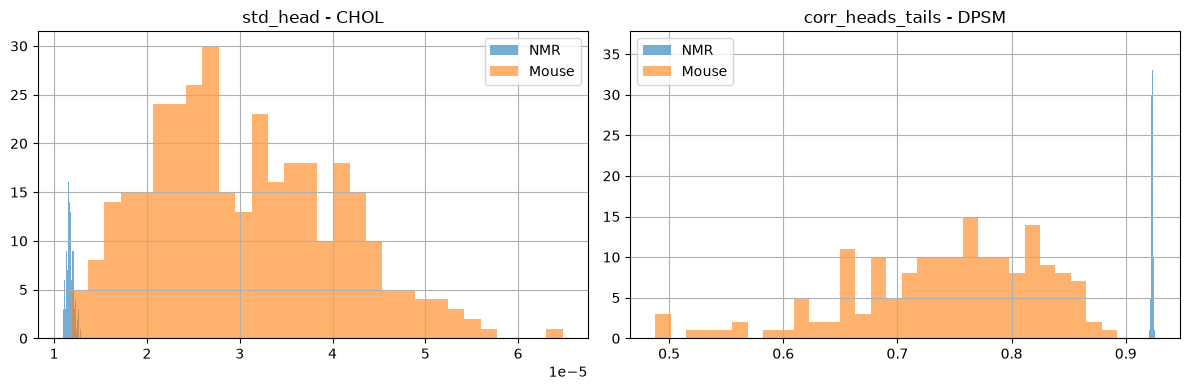

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# CHOL
df_chol[df_chol["target"] == 0]["std_head"].hist(
    bins=30, alpha=0.6, label="NMR", ax=axes[0]
)
df_chol[df_chol["target"] == 1]["std_head"].hist(
    bins=30, alpha=0.6, label="Mouse", ax=axes[0]
)
axes[0].set_title("std_head - CHOL")
axes[0].legend()

# DPSM
df_dpsm[df_dpsm["target"] == 0]["corr_heads_tails"].hist(
    bins=30, alpha=0.6, label="NMR", ax=axes[1]
)
df_dpsm[df_dpsm["target"] == 1]["corr_heads_tails"].hist(
    bins=30, alpha=0.6, label="Mouse", ax=axes[1]
)
axes[1].set_title("corr_heads_tails - DPSM")
axes[1].legend()

plt.tight_layout()
plt.show()

Con estas dos características podemos ver en la distribución que, aunque existe un solapamiento en `std_head`, son clave para la diferenciación de ambos grupos.

---

## Evaluación con test

In [13]:
# Entrenar modelos con CHOL
lr_baseline.fit(X_train_chol_scaled, y_train_chol)
rf_baseline.fit(X_train_chol_scaled, y_train_chol)
xgb_baseline.fit(X_train_chol_scaled, y_train_chol)

# Predicciones finales
y_pred_lr_chol = lr_baseline.predict(X_test_chol_scaled)
y_pred_rf_chol = rf_baseline.predict(X_test_chol_scaled)
y_pred_xgb_chol = xgb_baseline.predict(X_test_chol_scaled)


# Evaluación CHOL
def evaluate(y_true, y_pred, model_name, dataset="CHOL"):
    print(f"\n{dataset} - {model_name}:")
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  F1-Score:  {f1_score(y_true, y_pred, zero_division=0):.4f}")


evaluate(y_test_chol, y_pred_lr_chol, "Logistic Regression", "CHOL")
evaluate(y_test_chol, y_pred_rf_chol, "Random Forest", "CHOL")
evaluate(y_test_chol, y_pred_xgb_chol, "XGBoost", "CHOL")


# Entrenar modelos con DPSM
lr_baseline.fit(X_train_dpsm_scaled, y_train_dpsm)
rf_baseline.fit(X_train_dpsm_scaled, y_train_dpsm)
xgb_baseline.fit(X_train_dpsm_scaled, y_train_dpsm)

# Predicciones finales
y_pred_lr_dpsm = lr_baseline.predict(X_test_dpsm_scaled)
y_pred_rf_dpsm = rf_baseline.predict(X_test_dpsm_scaled)
y_pred_xgb_dpsm = xgb_baseline.predict(X_test_dpsm_scaled)

# Evaluación DPSM
evaluate(y_test_dpsm, y_pred_lr_dpsm, "Logistic Regression", "DPSM")
evaluate(y_test_dpsm, y_pred_rf_dpsm, "Random Forest", "DPSM")
evaluate(y_test_dpsm, y_pred_xgb_dpsm, "XGBoost", "DPSM")


CHOL - Logistic Regression:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

CHOL - Random Forest:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

CHOL - XGBoost:
  Accuracy:  0.9806
  Precision: 1.0000
  Recall:    0.9710
  F1-Score:  0.9853

DPSM - Logistic Regression:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

DPSM - Random Forest:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

DPSM - XGBoost:
  Accuracy:  0.9903
  Precision: 0.9714
  Recall:    1.0000
  F1-Score:  0.9855
